# Dataset Heart - Kaggle

Disponemos de datos que clasifican si los pacientes padecen o no una cardiopatía en función de las características que contienen. Intentaremos utilizar estos datos para crear un modelo que intente predecir si un paciente tiene esta enfermedad o no. Utilizaremos el algoritmo de RandomForest (clasificación).

- Fuente: https://www.kaggle.com/code/cdabakoglu/heart-disease-classifications-machine-learning/notebook

# Pasos ML
- Se recomienda datos estructurados, solución a un problema de clasificación a la
elección del estudiante (no visto en clases).

- Crear el CANVAS ML para el proyecto a desarrollar, implementar todo el pipeline de ciencia de datos y ML hasta tener los modelos entrenados en archivos PKL.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import os
import pickle

In [2]:
pip show scikit-learn


Name: scikit-learn
Version: 1.2.2
Summary: A set of python modules for machine learning and data mining
Home-page: http://scikit-learn.org
Author: 
Author-email: 
License: new BSD
Location: /usr/local/lib/python3.10/dist-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: fastai, imbalanced-learn, librosa, lightgbm, mlxtend, qudida, sklearn-pandas, yellowbrick


## **Cargamos la Base de Datos**

In [ ]:
# Conexión hacia google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Lectura de Datos

In [ ]:
# Leemos los datos desde nuestra ruta
df = pd.read_csv("/content/drive/MyDrive/Universidad de Manizales/3). Mestria GEI/17). Electiva II/Entregables/Entregable 02/heart.csv")

In [ ]:
# Mostramos el top 5 del set de datos
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Contenido de los datos: <br>

* **edad:** edad en años <br>
* **sexo:** (1 = masculino; 0 = femenino) <br>
* **cp:** tipo de dolor en el pecho <br>
* **trestbps:** presión arterial en reposo (en mm Hg al ingresar al hospital) <br>
* **col:** colesterol sérico en mg/dl <br>
* **fbs:** (azúcar en sangre en ayunas > 120 mg/dl) (1 = verdadero; 0 = falso) <br>
* **restecg:** resultados electrocardiográficos en reposo <br>
* **thalach:** frecuencia cardíaca máxima alcanzada <br>
* **exang:** angina inducida por ejercicio (1 = sí; 0 = no) <br>
* **oldpeak:** depresión del segmento ST inducida por el ejercicio en relación al reposo <br>
* **slope:** la pendiente del segmento ST del ejercicio máximo <br>
* **ca:** número de vasos principales (0-3) coloreados por fluoroscopia <br>
* **thal:** 3 = normal; 6 = defecto fijo; 7 = defecto reversible <br>
* **target:** tiene enfermedad o no (1=sí, 0=no)

## EDA

In [ ]:
# Contamos cantidad de valores únicos en el target
target_counts = df['target'].value_counts()
# Imprimimos el resultado con formato
print("Cantidad de muestras con el valor 1 (enfermedad cardíaca presente):", target_counts[1])
print("Cantidad de muestras con el valor 0 (enfermedad cardíaca ausente):", target_counts[0])

Cantidad de muestras con el valor 1 (enfermedad cardíaca presente): 165
Cantidad de muestras con el valor 0 (enfermedad cardíaca ausente): 138


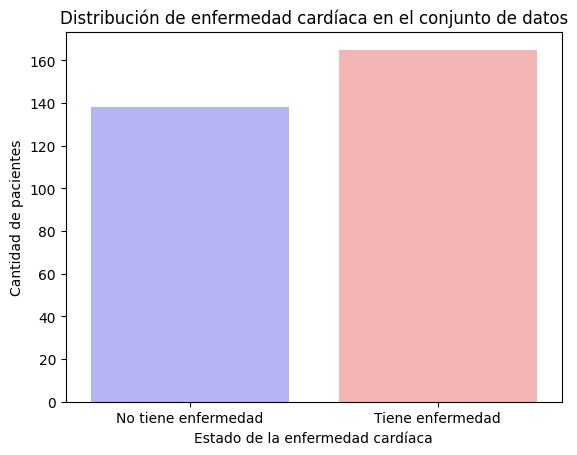

In [ ]:
# Creamos el gráfico de conteo
sns.countplot(x="target", data=df, palette="bwr")
# Personalizar las leyendas
plt.xlabel("Estado de la enfermedad cardíaca")
plt.ylabel("Cantidad de pacientes")
plt.title("Distribución de enfermedad cardíaca en el conjunto de datos")
plt.xticks([0, 1], ["No tiene enfermedad", "Tiene enfermedad"])

# Mostrar el gráfico
plt.show()


In [ ]:
# Porcentaje de pacientes que tienen y que no tienen enfermedad
# Contar la cantidad de pacientes que no tienen enfermedad cardíaca (target = 0)
cantidadSinEnfermedad = len(df[df.target == 0])
# Contar la cantidad de pacientes que tienen enfermedad cardíaca (target = 1)
cantidadConEnfermedad = len(df[df.target == 1])
# Calcular el porcentaje de pacientes que no tienen enfermedad cardíaca
porcentajeSinEnfermedad = (cantidadSinEnfermedad / len(df.target)) * 100
# Calcular el porcentaje de pacientes que tienen enfermedad cardíaca
porcentajeConEnfermedad = (cantidadConEnfermedad / len(df.target)) * 100
# Mostrar el porcentaje de pacientes que no tienen enfermedad cardíaca
print("Porcentaje de pacientes sin enfermedad cardíaca: {:.2f}%".format(porcentajeSinEnfermedad))
# Mostrar el porcentaje de pacientes que tienen enfermedad cardíaca
print("Porcentaje de pacientes con enfermedad cardíaca: {:.2f}%".format(porcentajeConEnfermedad))

Porcentaje de pacientes sin enfermedad cardíaca: 45.54%
Porcentaje de pacientes con enfermedad cardíaca: 54.46%


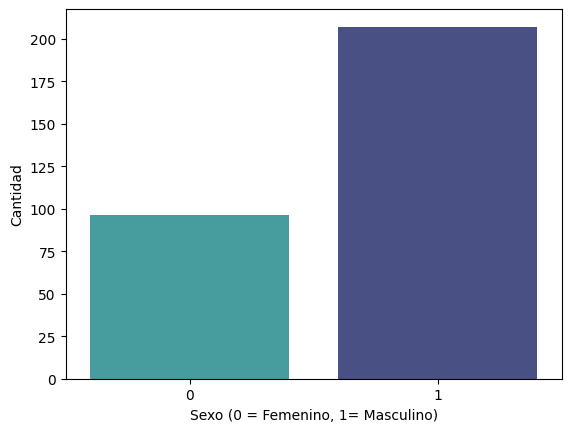

In [ ]:
# Distribución de género
sns.countplot(x='sex', data=df, palette="mako_r")
plt.xlabel("Sexo (0 = Femenino, 1= Masculino)")
plt.ylabel("Cantidad")
plt.show()

In [ ]:
countFemenino = len(df[df.sex == 0])
countMasculino = len(df[df.sex == 1])
print("Porcentaje de pacientes mujeres: {:.2f}%".format((countFemenino / (len(df.sex))*100)))
print("Porcentaje de pacientes hombres: {:.2f}%".format((countMasculino / (len(df.sex))*100)))

Porcentaje de pacientes mujeres: 31.68%
Porcentaje de pacientes hombres: 68.32%


In [ ]:
#Promedio de cada columna en el DataFrame
df.groupby('target').mean()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
target,,,,,,,,,,,,,
0,56.601449,0.826087,0.478261,134.398551,251.086957,0.159420,0.449275,139.101449,0.550725,1.585507,1.166667,1.166667,2.543478
1,52.496970,0.563636,1.375758,129.303030,242.230303,0.139394,0.593939,158.466667,0.139394,0.583030,1.593939,0.363636,2.121212


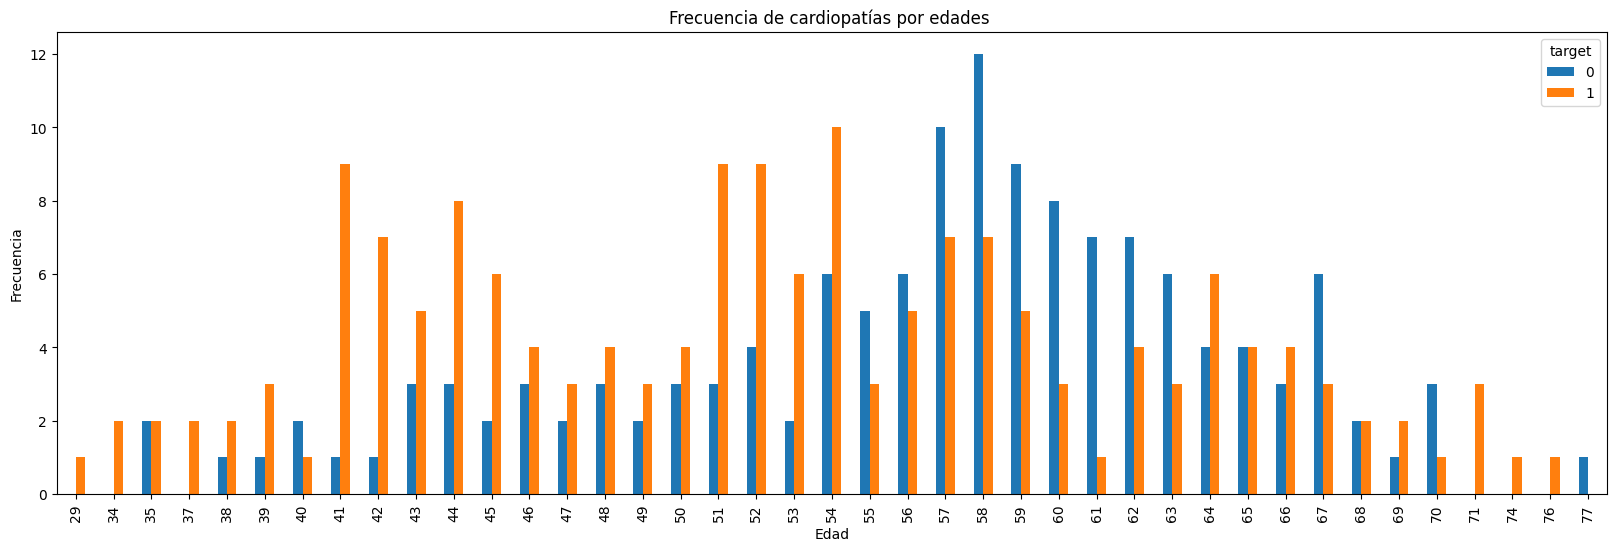

In [ ]:
# Mostramos enfermedad o no enfermedad en función de las edades
pd.crosstab(df.age,df.target).plot(kind="bar",figsize=(20,6))
plt.title('Frecuencia de cardiopatías por edades ')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

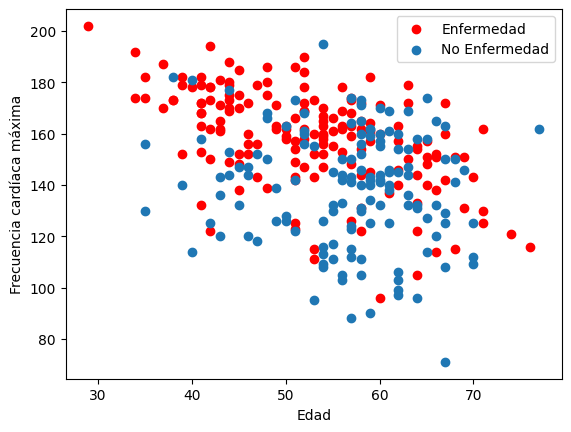

In [ ]:
# Diagrama de dispersión
plt.scatter(x=df.age[df.target==1], y=df.thalach[(df.target==1)], c="red")
plt.scatter(x=df.age[df.target==0], y=df.thalach[(df.target==0)])
plt.legend(["Enfermedad", "No Enfermedad"])
plt.xlabel("Edad")
plt.ylabel("Frecuencia cardíaca máxima")
plt.show()

## Creando Modelo de Regresión logística<br>

In [ ]:
# Separamos los valores:
# y: Contiene la variable objetivo (columna "target") que queremos predecir
y = df.target.values
# x_data: Contiene todas las características (variables independientes) que se utilizarán para hacer la predicción
x_data = df.drop(['target'], axis = 1)

### Normalización de los datos
<br>
<br>
<img src="https://beyondbacktesting.files.wordpress.com/2017/07/normalization.png?w=863" width="400px"/>

In [ ]:
# Llevamos los valores de la columna x a una escala entre 0 y 1, lo que significa que el valor mínimo de x será mapeado a 0 y el valor máximo de x será mapeado a 1.
# Los demás valores se escalan proporcionalmente en ese rango.
x = (x_data - np.min(x_data)) / (np.max(x_data) - np.min(x_data)).values

/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:84: FutureWarning: In a future version, DataFrame.min(axis=None) will return a scalar min over the entire DataFrame. To retain the old behavior, use 'frame.min(axis=0)' or just 'frame.min()'
  return reduction(axis=axis, out=out, **passkwargs)
/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:84: FutureWarning: In a future version, DataFrame.max(axis=None) will return a scalar max over the entire DataFrame. To retain the old behavior, use 'frame.max(axis=0)' or just 'frame.max()'
  return reduction(axis=axis, out=out, **passkwargs)
/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:84: FutureWarning: In a future version, DataFrame.min(axis=None) will return a scalar min over the entire DataFrame. To retain the old behavior, use 'frame.min(axis=0)' or just 'frame.min()'
  return reduction(axis=axis, out=out, **passkwargs)


Vamos a mantener la relación 80-20 % para datos de entrenamiento y pruebas respectivamente

In [ ]:
# Generando los grupos 80-20
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2,random_state=0)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.svm import SVC
modelo = RandomForestClassifier() #SVC() xgb.XGBClassifier() LogisticRegression()

In [ ]:
# Entrenar el modelo
modelo.fit(x_train, y_train)

RandomForestClassifier()

In [ ]:
print("Accuracy del modelo:", modelo.score(x_test, y_test))

Accuracy del modelo: 0.8852459016393442


In [ ]:
# Preparar nuevas características para la predicción (ejemplo)
nuevas_caracteristicas = [[63, 1, 3, 145, 233, 1, 0, 150, 0, 2.3, 0, 0, 1]]

In [ ]:
# Realizar la predicción para las nuevas características
prediccion = modelo.predict(nuevas_caracteristicas)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Interpretar la predicción
if prediccion[0] == 1:
    respuesta = "Sí"
else:
    respuesta = "No"

# Mostrar la respuesta
print("¿El paciente tiene enfermedad cardíaca?:", respuesta)

¿El paciente tiene enfermedad cardíaca?: Sí


## Exportando el Modelo

In [ ]:
with open('modelo.pkl','wb') as archivo:
  pickle.dump(modelo, archivo)